# GISLR — ASL phonology from landmarks: a phonological feature system and how consistent it is within and between signs (TODO §3.10)

**Dataset-stage diagnostic. No model is trained.** The user's request (2026-09-26): research the phonological
features of ASL, convert each `(T, 543, 3)` clip into phonological features only (all 543 landmarks in, no
subset), normalize coordinates to a fixed point, run everything **with and without** shoulder-width scaling,
and measure how alike the phonology of clips of the same gloss is and how different it is across glosses,
**with tolerance** for within-gloss variation. The goal behind it: fewer input parameters, more accuracy.

**The system** (`sb.recognize.phonology`): 130 per-frame features grouped by phonological parameter —
handshape 50, orientation 12, location 29, contact 2, movement 15, hand arrangement 10, non-manual 10,
presence 2 — against 1,629 raw coordinates. Coordinates are anchored at the mid-shoulder point, mirrored so
+x is always the dominant side, and (scaled variant) divided by the clip's shoulder width. Research
background and every feature's definition: `docs/reports/asl-phonology-features.md`.

**Per clip:** the mean of each third of the clip (onset / medial / final, after the hold-movement-hold model)
and the std over the clip (4 × 130 = 520 numbers), and 18 discrete phonological codes (selected fingers,
flexion, spread, thumb, palm and finger direction, major/minor location, contact, movement, path direction,
repetition, handshape and orientation change, sign type, brows, mouth). The raw-landmark baseline gets the same
anchor, mirror, scale and summary (4 × 1,629 = 6,516 numbers), and a second baseline without the 468-point
face mesh (hands + pose, 4 × 225 = 900), since the face makes up 86% of the raw columns.

**Tests** (both variants; the phonology per parameter, manual-only, all, and the raw baseline):
- pairs of clips, same gloss vs different gloss (50,000 each, train clips; also same gloss across signers):
  cosine and distance distributions, Cohen's d, ROC AUC;
- **tolerance, continuous**: share of features on which two clips agree within τ = 0.25 / 0.5 / 1 SD;
- **tolerance, discrete**: two clips' code combinations match if at most m codes differ (m = 0–6);
  each gloss's modal combination, how many of its clips are within m of it, how unique it is;
- Fisher ratio and η² per feature; silhouette; share of separable glosses; effective dimensionality (PCA);
- nearest mean template (train → test) top-1/top-5 and 1-nearest-neighbour — no fitted weights;
- validity: each code against the gloss's ASL-LEX 2.0 code;
- per gloss and per signer.

| artifact | path |
|---|---|
| per-clip summaries, codes, sequences (resumable chunks) | `data/cache/gislr/phonology_features/chunks/chunk_<k>.{npz,parquet}` |
| every statistic, as CSV/JSON | `data/cache/gislr/phonology_features/results/` |
| figures | `data/cache/gislr/phonology_features/assets/*.png` |

**Resumable:** a chunk whose parquet exists is skipped. Every later section reads the chunks from disk
(`load_tables()`, cached per kernel) and writes its own results file, so any section can be re-run alone.

**Design decisions vs the request:** (1) the anchor is the mid-shoulder point, the centre of the signing
space; (2) hand shape and orientation are ratios and angles inside the hand, so scaling cannot change them —
scaling only touches the 45 length/velocity features; (3) GISLR almost never has both hands in one frame
(0.28% of frames, identical in the original competition parquet), so the non-dominant hand and sign type are
read from the pose arms, which are present in every frame; (4) movement codes use the sign nucleus (the
middle 60% of the dominant hand's detected span), leaving out the rise from rest and the return.

## 1. Setup

In [1]:
# ============================================================
# Imports, tunables, paths, cached loaders
# ============================================================
import json
import os
import warnings
from concurrent.futures import ProcessPoolExecutor
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, gislr_dir
from sb.recognize import aslex
from sb.recognize import phonology as PH
from sb.recognize import phonology_stats as ST

CHUNK = 5000              # clips per resumable chunk
WORKERS = 12              # extraction processes
SEED = 42                 # every sampled pair and subsample
N_PAIRS = 50_000          # same-gloss and different-gloss pairs, train clips
TAUS = (0.25, 0.5, 1.0)   # continuous tolerance: agreement within tau standard deviations
TOLERANCES = range(0, 7)  # discrete tolerance: at most m differing codes
SIL_PER_CLASS = 40        # clips per gloss for the silhouette
VARIANTS = ("unscaled", "scaled")
SMOKE = int(os.environ.get("PHONO_SMOKE", 0))  # >0: that many clips per gloss into data/temp, a quick end-to-end check

DATA = gislr_dir()
OUT = CACHE_DIR / "gislr" / "phonology_features"
CH, RES, ASSETS = OUT / "chunks", OUT / "results", OUT / "assets"
for d in (CH, RES, ASSETS):
    d.mkdir(parents=True, exist_ok=True)
CLIPS = pd.concat([pd.read_csv(DATA / "train.csv"), pd.read_csv(DATA / "test.csv")], ignore_index=True)
if SMOKE:
    CLIPS = CLIPS.groupby(["sign", "split"]).head(SMOKE)
    OUT = CACHE_DIR.parent / "temp" / "phonology_features_smoke"
    CH, RES, ASSETS = OUT / "chunks", OUT / "results", OUT / "assets"
    for d in (CH, RES, ASSETS):
        d.mkdir(parents=True, exist_ok=True)
SCOPES = {**{p: PH.GROUP == p for p in PH.PARAMETERS},
          "manual": ~np.isin(PH.GROUP, ["non_manual"]), "all": np.ones(PH.F, bool)}
# the raw baseline without the 468-point face mesh (hands + pose): 86% of the raw columns are face
RAW_NO_FACE = np.tile(np.arange(PH.RAW_DIMS) >= PH.LH0 * 3, 4)
warnings.filterwarnings("ignore", message="(Mean of empty slice|All-NaN slice|Degrees of freedom)")


def summary_mask(features: np.ndarray) -> np.ndarray:
    """The 4 summary blocks (onset, medial, final means; std) of the selected features."""
    return np.tile(features, 4)


@lru_cache(maxsize=1)
def load_tables():
    """(clip table with info + codes, {variant: {"phono": (N, 520), "raw": (N, 6516)}}), from the chunks."""
    files = sorted(CH.glob("chunk_*.parquet"))
    assert files, "run section 2 first"
    T = pd.concat([pd.read_parquet(f) for f in files]).set_index("row").sort_index()
    S = {v: {"phono": [], "raw": []} for v in VARIANTS}
    for f in files:
        z = np.load(f.with_suffix(".npz"))
        for v in VARIANTS:
            S[v]["phono"].append(z[f"summary_{v}"])
            S[v]["raw"].append(z[f"raw_{v}"])
    S = {v: {k: np.concatenate(x) for k, x in d.items()} for v, d in S.items()}
    assert len(T) == len(CLIPS), f"{len(T)} of {len(CLIPS)} clips extracted"
    return T, S


@lru_cache(maxsize=1)
def pairs():
    """Fixed train pairs: same gloss, different gloss, same gloss + different signer, same gloss + same signer."""
    T, _ = load_tables()
    tr = np.flatnonzero(T.split.to_numpy() == "train")
    y, sig = T.sign.to_numpy()[tr], T.participant_id.to_numpy()[tr]
    rng = np.random.default_rng(SEED)
    same = tr[ST.sample_pairs(y, N_PAIRS, rng, same=True)]
    diff = tr[ST.sample_pairs(y, N_PAIRS, rng, same=False)]
    cross = tr[ST.sample_pairs(y, N_PAIRS, rng, same=True, group=sig, same_group=False)]
    within = tr[ST.sample_pairs(y, N_PAIRS, rng, same=True, group=sig, same_group=True)]
    return same, diff, cross, within


print(f"GISLR: {DATA}\n{len(CLIPS)} clips ({(CLIPS.split == 'train').sum()} train / {(CLIPS.split == 'test').sum()} test), "
      f"{CLIPS.sign.nunique()} glosses, {CLIPS.participant_id.nunique()} signers\n"
      f"{PH.F} phonological features per frame vs {PH.RAW_DIMS} raw coordinates\nresults -> {OUT}")

GISLR: C:\Users\user2\.cache\kagglehub\datasets\bracu23101281\gislr-stratified\versions\1
94477 clips (75581 train / 18896 test), 250 glosses, 21 signers
130 phonological features per frame vs 1629 raw coordinates
results -> C:\Users\user2\repository\data\cache\gislr\phonology_features


## 2. The feature catalog

Every feature, the phonological parameter it measures, its unit, and whether the scaled variant divides it by
the shoulder width. Written to `results/catalog.csv`.

In [2]:
# ============================================================
# Feature catalog: counts per parameter
# ============================================================
cat = pd.DataFrame([{"feature": f.name, "parameter": f.parameter, "unit": f.unit, "scaled": bool(s),
                     "meaning": f.meaning} for f, s in zip(PH.CATALOG, PH.SCALED)])
cat.to_csv(RES / "catalog.csv", index=False)
print(cat.groupby("parameter").agg(features=("feature", "size"), scaled=("scaled", "sum")).to_string())
print(f"\ntotal {len(cat)} per frame ({cat.scaled.sum()} scale-dependent) -> {4 * len(cat)} per clip; "
      f"raw: {PH.RAW_DIMS} per frame -> {4 * PH.RAW_DIMS} per clip ({PH.RAW_DIMS / len(cat):.1f}x more)")

                  features  scaled
parameter                         
contact                  2       2
hand_arrangement        10       6
handshape               50       0
location                29      28
movement                15       9
non_manual              10       0
orientation             12       0
presence                 2       0

total 130 per frame (45 scale-dependent) -> 520 per clip; raw: 1629 per frame -> 6516 per clip (12.5x more)


## 3. Extract every clip (resumable)

`PH.clip_record` per clip: features, both variants' summaries and codes, the raw baseline's summaries, and the
unscaled sequence resampled to 32 steps (kept for later sequence work). One `.npz` + `.parquet` per chunk,
written atomically; the parquet is the done-marker.

In [3]:
# ============================================================
# Every clip -> phonological record; one chunk at a time
# ============================================================
chunks = [(k, CLIPS.iloc[s:s + CHUNK]) for k, s in enumerate(range(0, len(CLIPS), CHUNK))]
todo = [(k, c) for k, c in chunks if not (CH / f"chunk_{k:03d}.parquet").exists()]
bar = tqdm(total=sum(len(c) for _, c in todo), desc="phonology features")
with ProcessPoolExecutor(WORKERS) as ex:
    for k, c in todo:
        recs = []
        for r in ex.map(PH.clip_record, [str(DATA / p) for p in c.npz_relpath], chunksize=32):
            recs.append(r)
            bar.update()
        arrays = {f"summary_{v}": np.stack([r[v]["summary"] for r in recs]) for v in VARIANTS}
        arrays |= {f"raw_{v}": np.stack([r[v]["raw"] for r in recs]) for v in VARIANTS}
        arrays["seq"] = np.stack([r["seq"] for r in recs])
        tmp = CH / f"chunk_{k:03d}.tmp.npz"
        np.savez(tmp, **arrays)
        os.replace(tmp, CH / f"chunk_{k:03d}.npz")
        t = pd.DataFrame({"row": c.index, "sign": c.sign.to_numpy(), "split": c.split.to_numpy(),
                          "participant_id": c.participant_id.to_numpy()})
        t = pd.concat([t, pd.DataFrame([r["info"] for r in recs])], axis=1)
        for v in VARIANTS:
            for name in PH.CODES:
                t[f"{v}:{name}"] = [r[v]["codes"][name] for r in recs]
        t["h1_share"] = [r["h1_share"] for r in recs]
        t["h2_share"] = [r["h2_share"] for r in recs]
        tmp = CH / f"chunk_{k:03d}.tmp.parquet"
        t.to_parquet(tmp)
        os.replace(tmp, CH / f"chunk_{k:03d}.parquet")
bar.close()
T, S = load_tables()
print(T.shape, {v: {k: x.shape for k, x in d.items()} for v, d in S.items()})

phonology features: 0it [00:00, ?it/s]

(94477, 41) {'unscaled': {'phono': (94477, 520), 'raw': (94477, 6516)}, 'scaled': {'phono': (94477, 520), 'raw': (94477, 6516)}}


## 4. Extraction quality: what the landmarks actually contain

Frames, dominance, hand detection, the two-hands problem, the non-dominant arm, shoulder width (how much the
scale varies at all), and each feature's missing rate. Written to `results/qc.json`, `results/missing.csv`.

clips                              94477
no_shoulders                       0
frames_median                      22.0
frames_p95                         135.0
left_dominant_share                0.4239762058490426
dominant_hand_frames_mean          0.6542383029097842
nondominant_hand_frames_mean       0.005360350080415137
clips_without_dominant_hand        0.0
both_hands_frames_mean             0.002696452895179391
clips_with_any_both_hands_frame    0.025424177312996815
nondominant_arm_raised_share       0.13185219683097474
shoulder_width_median              0.5632938146591187
shoulder_width_cv                  0.11054806224717459
shoulder_width_p5_p95              [0.4679359018802643, 0.6685162663459777]

missing rate (medial third) by parameter:
 parameter
contact             0.579
hand_arrangement    0.494
handshape           0.578
location            0.547
movement            0.584
non_manual          0.001
orientation         0.578
presence            0.000


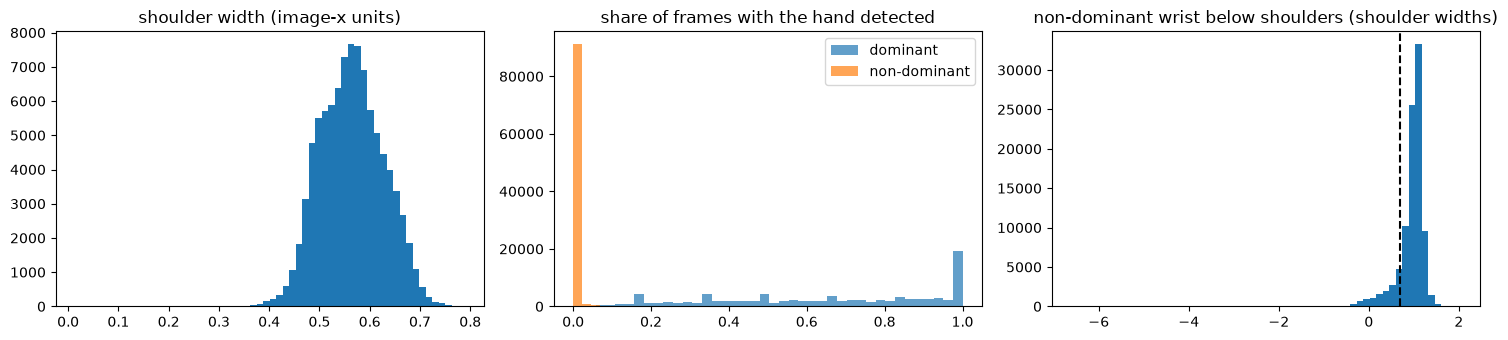

In [4]:
# ============================================================
# Extraction QC
# ============================================================
T, S = load_tables()
medial = lambda v, name: S[v]["phono"][:, PH.F + PH.IDX[name]]  # noqa: E731  (medial-third mean)
thirds = lambda v, name: np.nanmean(S[v]["phono"][:, [b * PH.F + PH.IDX[name] for b in range(3)]], axis=1)  # noqa: E731
both = thirds("scaled", "both_present")
h2_raised = medial("scaled", "h2_wrist_y") < PH.RAISED_T
qc = {
    "clips": len(T), "no_shoulders": int((T.kept == 0).sum()),
    "frames_median": float(T.frames.median()), "frames_p95": float(T.frames.quantile(0.95)),
    "left_dominant_share": float((T.dominant == "left").mean()),
    "dominant_hand_frames_mean": float(T.h1_share.mean()), "nondominant_hand_frames_mean": float(T.h2_share.mean()),
    "clips_without_dominant_hand": float((T.h1_share == 0).mean()),
    "both_hands_frames_mean": float(np.nanmean(both)), "clips_with_any_both_hands_frame": float(np.nanmean(both > 0)),
    "nondominant_arm_raised_share": float(np.nanmean(h2_raised)),
    "shoulder_width_median": float(T.width.median()), "shoulder_width_cv": float(T.width.std() / T.width.mean()),
    "shoulder_width_p5_p95": [float(T.width.quantile(0.05)), float(T.width.quantile(0.95))],
}
json.dump(qc, open(RES / "qc.json", "w"), indent=1)
for k, v in qc.items():
    print(f"{k:34s} {v}")
miss = pd.DataFrame({"feature": PH.NAMES, "parameter": PH.GROUP,
                     "missing_medial": np.isnan(S["scaled"]["phono"][:, PH.F:2 * PH.F]).mean(0)})
miss.to_csv(RES / "missing.csv", index=False)
print("\nmissing rate (medial third) by parameter:\n", miss.groupby("parameter").missing_medial.mean().round(3).to_string())
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].hist(T.width.dropna(), 60); ax[0].set_title("shoulder width (image-x units)")
ax[1].hist(T.h1_share, 40, alpha=.7, label="dominant"); ax[1].hist(T.h2_share, 40, alpha=.7, label="non-dominant")
ax[1].set_title("share of frames with the hand detected"); ax[1].legend()
ax[2].hist(medial("scaled", "h2_wrist_y")[np.isfinite(medial("scaled", "h2_wrist_y"))], 60)
ax[2].axvline(PH.RAISED_T, color="k", ls="--"); ax[2].set_title("non-dominant wrist below shoulders (shoulder widths)")
fig.tight_layout(); fig.savefig(ASSETS / "qc.png", dpi=110); plt.show()

## 5. Continuous similarity: same gloss vs different gloss, per parameter, both variants, vs raw landmarks

For each variant × scope: dimensions and effective dimensionality; the pair statistics (same-gloss pairs,
different-gloss pairs, and same-gloss pairs **across signers**); tolerant agreement (share of features within
τ SD); silhouette; separable-gloss share; nearest-template and 1-NN accuracy train → test.
Written to `results/continuous.csv`.

continuous stats:   0%|          | 0/22 [00:00<?, ?it/s]

 variant            scope  dims  pca95  intra_cos_mean  inter_cos_mean  cohen_d_cos  auc_cos  auc_cos_cross_signer  same_agree@0.5  diff_agree@0.5  silhouette  separable_share  template_top1  template_top5  knn1_top1
unscaled        handshape   200     50           0.331           0.003        1.055    0.770                 0.763           0.716           0.660      -0.186            0.992          0.258          0.493      0.398
unscaled      orientation    48     20           0.267           0.005        0.736    0.698                 0.689           0.687           0.645      -0.281            0.896          0.103          0.284      0.158
unscaled         location   116     23           0.219           0.010        0.571    0.655                 0.646           0.675           0.638      -0.265            0.816          0.095          0.240      0.204
unscaled          contact     8      4           0.205           0.045        0.261    0.576                 0.568           0.707  

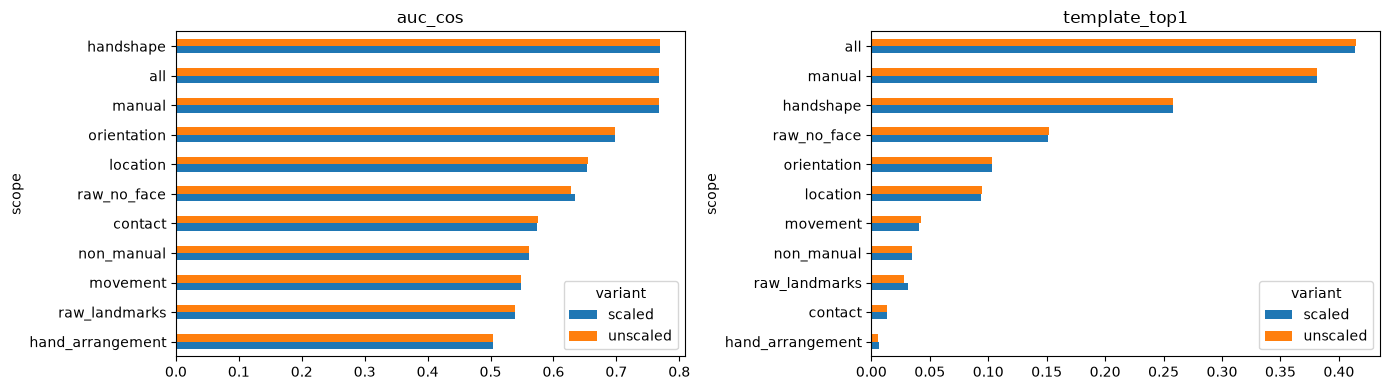

In [5]:
# ============================================================
# Continuous similarity statistics, every variant x scope
# ============================================================
T, S = load_tables()
same, diff, cross, within = pairs()
y = T.sign.to_numpy()
tr, te = T.split.to_numpy() == "train", T.split.to_numpy() == "test"
classes = np.sort(T.sign.unique())
rows = []
scopes = [(v, s, S[v]["phono"][:, summary_mask(m)]) for v in VARIANTS for s, m in SCOPES.items()]
scopes += [(v, "raw_landmarks", S[v]["raw"]) for v in VARIANTS]
scopes += [(v, "raw_no_face", S[v]["raw"][:, RAW_NO_FACE]) for v in VARIANTS]
bar = tqdm(scopes, desc="continuous stats")
for v, scope, X in bar:
    bar.set_postfix_str(f"{v}/{scope}")
    rng = np.random.default_rng(SEED)
    Z, keep = ST.standardize(X, tr)
    r = {"variant": v, "scope": scope, "dims": int(keep.sum()), **ST.effective_dims(Z[tr], rng)}
    r |= ST.pair_stats(Z, same, diff)
    cs, _ = ST.pair_similarity(Z, cross)
    ws, _ = ST.pair_similarity(Z, within)
    r |= {"intra_cos_cross_signer": float(cs.mean()), "intra_cos_same_signer": float(ws.mean()),
          "auc_cos_cross_signer": ST._auc(cs, ST.pair_similarity(Z, diff)[0])}
    r |= {f"same_{k}": x for k, x in ST.tolerance_agreement(Z, same, TAUS).items()}
    r |= {f"diff_{k}": x for k, x in ST.tolerance_agreement(Z, diff, TAUS).items()}
    r["silhouette"] = ST.silhouette(Z[tr], y[tr], SIL_PER_CLASS, rng)
    r["separable_share"], _ = ST.separable_share(Z[tr], y[tr], Z[te], y[te], classes)
    ce = ST.centroid_eval(Z[tr], y[tr], Z[te], y[te], classes)
    r |= {"template_top1": ce["top1"], "template_top5": ce["top5"], "knn1_top1": ST.knn_eval(Z[tr], y[tr], Z[te], y[te])}
    rows.append(r)
CONT = pd.DataFrame(rows)
CONT.to_csv(RES / "continuous.csv", index=False)
show = ["variant", "scope", "dims", "pca95", "intra_cos_mean", "inter_cos_mean", "cohen_d_cos", "auc_cos",
        "auc_cos_cross_signer", "same_agree@0.5", "diff_agree@0.5", "silhouette", "separable_share",
        "template_top1", "template_top5", "knn1_top1"]
print(CONT[show].round(3).to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, metric in enumerate(["auc_cos", "template_top1"]):
    p = CONT.pivot(index="scope", columns="variant", values=metric).sort_values("scaled")
    p.plot.barh(ax=ax[i]); ax[i].set_title(metric)
fig.tight_layout(); fig.savefig(ASSETS / "continuous.png", dpi=110); plt.show()

## 6. Which features separate glosses: Fisher ratio and η² per feature

Between-gloss variance over within-gloss variance, on train clips; per summary column (feature × onset /
medial / final / std) and per parameter. The raw baseline's columns on a 20,000-clip subsample.
Written to `results/fisher_<variant>.csv`, `results/fisher_by_parameter.csv`.

--- unscaled: top 15 summary columns by Fisher ratio
                                 parameter  fisher   eta2  missing
medial:h1_nonbase_flex_ring      handshape   1.847  0.649    0.174
medial:h1_nonbase_flex_middle    handshape   1.723  0.633    0.174
medial:h1_nonbase_flex_pinky     handshape   1.652  0.623    0.174
medial:h1_palm_z               orientation   1.452  0.592    0.174
medial:h1_ext_ring               handshape   1.442  0.590    0.174
medial:h1_ext_middle             handshape   1.434  0.589    0.174
medial:h1_nonbase_flex_index     handshape   1.271  0.560    0.174
medial:h1_ext_pinky              handshape   1.254  0.556    0.174
medial:h1_spread_index_middle    handshape   1.216  0.549    0.174
medial:h2_accel                   movement   1.210  0.548    0.993
onset:h1_nonbase_flex_ring       handshape   1.133  0.531    0.096
medial:h1_spread_ring_pinky      handshape   1.095  0.523    0.174
onset:h1_nonbase_flex_middle     handshape   1.093  0.522    0.096
final:h1_

--- scaled: top 15 summary columns by Fisher ratio
                                 parameter  fisher   eta2  missing
medial:h1_nonbase_flex_ring      handshape   1.847  0.649    0.174
medial:h1_nonbase_flex_middle    handshape   1.723  0.633    0.174
medial:h1_nonbase_flex_pinky     handshape   1.652  0.623    0.174
medial:h1_palm_z               orientation   1.452  0.592    0.174
medial:h1_ext_ring               handshape   1.442  0.590    0.174
medial:h1_ext_middle             handshape   1.434  0.589    0.174
medial:h2_accel                   movement   1.300  0.565    0.993
medial:h1_nonbase_flex_index     handshape   1.271  0.560    0.174
medial:h1_ext_pinky              handshape   1.254  0.556    0.174
medial:h1_spread_index_middle    handshape   1.216  0.549    0.174
onset:h1_nonbase_flex_ring       handshape   1.133  0.531    0.096
medial:h1_spread_ring_pinky      handshape   1.095  0.523    0.174
onset:h1_nonbase_flex_middle     handshape   1.093  0.522    0.096
final:h1_no


median Fisher / eta^2 per parameter:
                   unscaled:fisher  unscaled:eta2  unscaled:missing  scaled:fisher  scaled:eta2  scaled:missing
parameter                                                                                                     
contact                     0.189          0.159             0.567          0.190        0.160           0.567
hand_arrangement            0.108          0.094             0.488          0.111        0.096           0.488
handshape                   0.309          0.236             0.566          0.309        0.236           0.566
location                    0.230          0.187             0.177          0.235        0.190           0.177
movement                    0.104          0.094             0.281          0.104        0.094           0.281
non_manual                  0.055          0.052             0.001          0.055        0.052           0.001
orientation                 0.254          0.202             0.566       

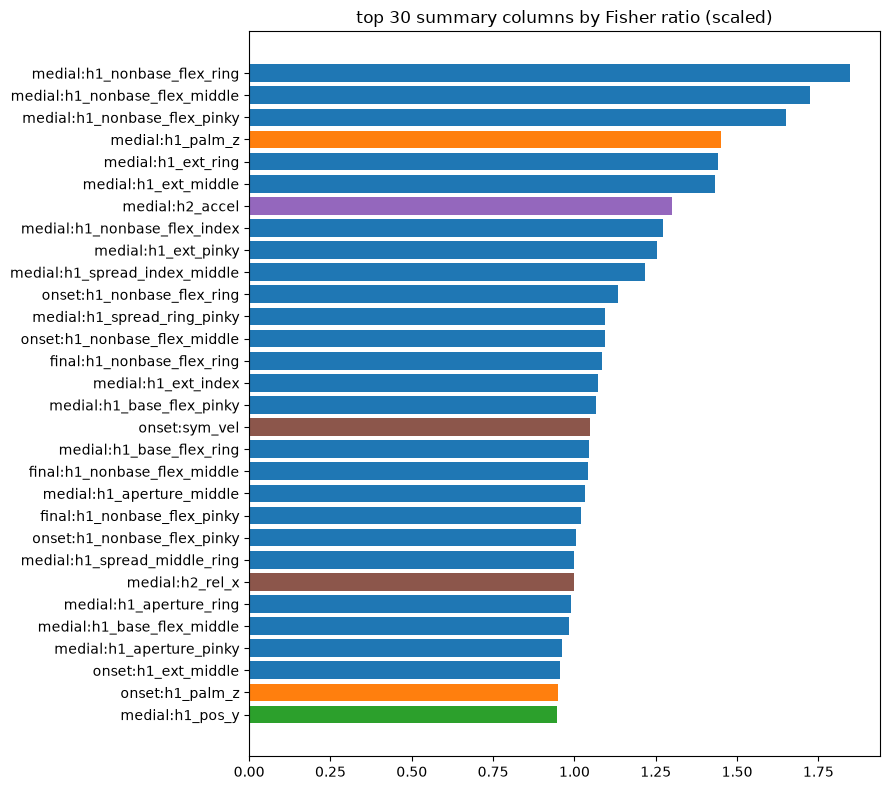

In [6]:
# ============================================================
# Fisher ratio / eta^2 per feature, both variants
# ============================================================
T, S = load_tables()
tr = T.split.to_numpy() == "train"
y = T.sign.to_numpy()
cols = [f"{b}:{n}" for b in ("onset", "medial", "final", "std") for n in PH.NAMES]
params = np.tile(PH.GROUP, 4)
by_param = []
for v in VARIANTS:
    fz = ST.fisher(S[v]["phono"][tr], y[tr])
    fz.index = cols
    fz.insert(0, "parameter", params)
    fz.to_csv(RES / f"fisher_{v}.csv")
    by_param.append(fz.groupby("parameter")[["fisher", "eta2", "missing"]].median().add_prefix(f"{v}:"))
    print(f"--- {v}: top 15 summary columns by Fisher ratio")
    print(fz.sort_values("fisher", ascending=False).head(15).round(3).to_string())
rng = np.random.default_rng(SEED)
sub = rng.choice(np.flatnonzero(tr), min(20000, int(tr.sum())), replace=False)
raw = {v: ST.fisher(S[v]["raw"][sub].astype(np.float32), y[sub]) for v in VARIANTS}
BP = pd.concat(by_param, axis=1)
for v in VARIANTS:
    BP.loc["raw_landmarks", [f"{v}:fisher", f"{v}:eta2", f"{v}:missing"]] = raw[v][["fisher", "eta2", "missing"]].median().to_numpy()
BP.to_csv(RES / "fisher_by_parameter.csv")
print("\nmedian Fisher / eta^2 per parameter:\n", BP.round(3).to_string())
fz = pd.read_csv(RES / "fisher_scaled.csv", index_col=0).sort_values("fisher", ascending=False).head(30)
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(fz.index[::-1], fz.fisher[::-1], color=[plt.cm.tab10(list(PH.PARAMETERS + ("presence",)).index(p)) for p in fz.parameter[::-1]])
ax.set_title("top 30 summary columns by Fisher ratio (scaled)"); fig.tight_layout()
fig.savefig(ASSETS / "fisher_top30.png", dpi=110); plt.show()

## 7. Discrete phonological combinations, with tolerance

Each clip's 18 codes (16 from `PH.codes`, plus brows and mouth, relative to the signer's own median). Per code:
how consistent a gloss's clips are (modal share, entropy) vs chance, and its normalized mutual information with
the gloss. Per tolerance m: the chance that two clips' combinations match with at most m differing codes, same
gloss vs different gloss; each gloss's modal combination ("signature"), how many of its clips lie within m of
it, and how many other glosses' signatures do. Written to `results/codes_*`.

=============== unscaled
                    n_values     na  within_modal_share  within_entropy  chance_modal_share  nmi_gloss
code                                                                                                  
selected_fingers          17  0.000               0.671           0.449               0.416      0.201
flexion                    4  0.000               0.680           0.588               0.376      0.136
spread                     3  0.459               0.755           0.549               0.459      0.126
thumb                      2  0.000               0.726           0.781               0.634      0.038
thumb_contact              2  0.000               0.765           0.702               0.669      0.048
palm_dir                   6  0.000               0.633           0.562               0.329      0.143
finger_dir                 6  0.000               0.717           0.537               0.631      0.068
major_location             3  0.000             

=============== scaled
                    n_values     na  within_modal_share  within_entropy  chance_modal_share  nmi_gloss
code                                                                                                  
selected_fingers          17  0.000               0.671           0.449               0.416      0.201
flexion                    4  0.000               0.680           0.588               0.376      0.136
spread                     3  0.459               0.755           0.549               0.459      0.126
thumb                      2  0.000               0.726           0.781               0.634      0.038
thumb_contact              2  0.000               0.765           0.702               0.669      0.048
palm_dir                   6  0.000               0.633           0.562               0.329      0.143
finger_dir                 6  0.000               0.717           0.537               0.631      0.068
major_location             3  0.000               

 variant  distinct_combinations  within_0  within_1  within_2  within_3
unscaled                  64049     0.011     0.054     0.142     0.278
  scaled                  63929     0.011     0.054     0.142     0.278


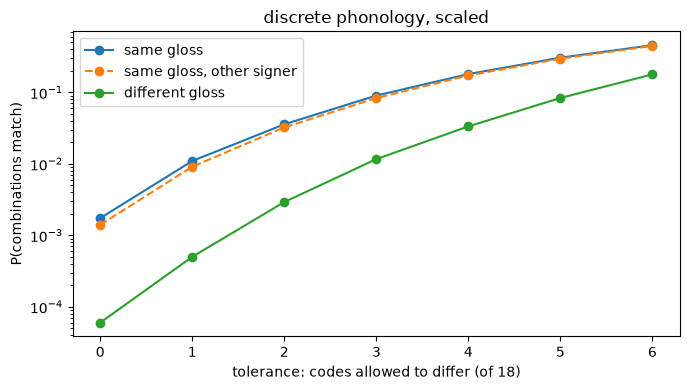

In [7]:
# ============================================================
# Codes: consistency, tolerant combination matching, signatures
# ============================================================
T, S = load_tables()
same, diff, cross, within = pairs()
y = T.sign.to_numpy()


def nonmanual_codes(v: str) -> pd.DataFrame:
    """Brows raised / neutral / lowered and mouth open / closed vs the signer's own median (robust z > 1)."""
    out = {}
    for code_name, feats, labels in (("brows", ["brow_raise_r", "brow_raise_l"], ("lowered", "neutral", "raised")),
                                     ("mouth", ["mouth_open"], ("closed", "closed", "open"))):
        x = np.nanmean(S[v]["phono"][:, [PH.F + PH.IDX[f] for f in feats]], axis=1)
        s = pd.Series(x).groupby(T.participant_id.to_numpy())
        med, mad = s.transform("median"), s.transform(lambda a: (a - a.median()).abs().median() * 1.4826 + 1e-9)
        z = ((pd.Series(x) - med) / mad).to_numpy()
        out[code_name] = np.where(np.isnan(z), "na", np.where(z > 1, labels[2], np.where(z < -1, labels[0], labels[1])))
    return pd.DataFrame(out, index=T.index)


summary = []
for v in VARIANTS:
    codes = T[[f"{v}:{c}" for c in PH.CODES]].rename(columns=lambda c: c.split(":")[1])
    codes = pd.concat([codes, nonmanual_codes(v)], axis=1)
    codes.to_parquet(RES / f"codes_{v}.parquet")
    cons = ST.code_consistency(codes, y)
    cons.to_csv(RES / f"codes_consistency_{v}.csv")
    M, na = ST.encode(codes)
    cm = ST.combo_match(M, na, same, diff, TOLERANCES)
    cm["p_match_same_cross_signer"] = [float((ST.mismatches(M, na, cross) <= m).mean()) for m in TOLERANCES]
    cm.to_csv(RES / f"codes_combo_match_{v}.csv", index=False)
    sig = ST.modal_combos(codes, y)
    sig.to_csv(RES / f"codes_signatures_{v}.csv")
    uq = ST.combo_uniqueness(sig, list(codes.columns))
    uq.to_csv(RES / f"codes_uniqueness_{v}.csv", index=False)
    values = pd.concat({c: codes[c].value_counts(normalize=True) for c in codes.columns}).rename("share")
    values.to_csv(RES / f"codes_values_{v}.csv")
    print(f"=============== {v}")
    print(cons.round(3).to_string())
    print("\ncombination match by tolerance (m = max differing codes of 18):\n", cm.round(4).to_string(index=False))
    print("\nclips within m codes of their gloss's signature (mean over glosses):",
          sig[[f"within_{m}" for m in (0, 1, 2, 3)]].mean().round(3).to_dict())
    print("signature uniqueness:\n", uq.round(3).to_string(index=False))
    summary.append({"variant": v, "distinct_combinations": int(codes.astype(str).agg("|".join, axis=1).nunique()),
                    **{f"within_{m}": float(sig[f"within_{m}"].mean()) for m in (0, 1, 2, 3)}})
pd.DataFrame(summary).to_csv(RES / "codes_summary.csv", index=False)
print(pd.DataFrame(summary).round(3).to_string(index=False))
cm = pd.read_csv(RES / "codes_combo_match_scaled.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cm.tolerance, cm.p_match_same, "o-", label="same gloss")
ax.plot(cm.tolerance, cm.p_match_same_cross_signer, "o--", label="same gloss, other signer")
ax.plot(cm.tolerance, cm.p_match_diff, "o-", label="different gloss")
ax.set_xlabel("tolerance: codes allowed to differ (of 18)"); ax.set_ylabel("P(combinations match)")
ax.set_yscale("log"); ax.legend(); ax.set_title("discrete phonology, scaled"); fig.tight_layout()
fig.savefig(ASSETS / "combo_match.png", dpi=110); plt.show()

## 7b. Fewer codes: only the ones that carry the sign

§7 shows several codes carry almost no information about the gloss (within-gloss agreement no better than
chance). Here the codes are ranked by NMI with the gloss **on train clips only**, the informative ones
(NMI ≥ `MIN_NMI`) kept, and the tolerance analysis repeated on that smaller combination. Then a purely
discrete classifier: every test clip goes to the gloss whose **train** signature it differs from in the
fewest codes (ties split fairly), for the full 18 codes and for the reduced set.
Written to `results/codes_reduced_<variant>.csv`, `results/codes_signature_accuracy.csv`.

In [8]:
# ============================================================
# Informative codes only: tolerance matching + signature classification
# ============================================================
MIN_NMI = 0.04   # keep codes whose NMI with the gloss (train clips) is at least this

T, _ = load_tables()
same, diff, cross, within = pairs()
y = T.sign.to_numpy()
tr, te = T.split.to_numpy() == "train", T.split.to_numpy() == "test"
acc_rows = []
for v in VARIANTS:
    codes = pd.read_parquet(RES / f"codes_{v}.parquet").loc[T.index]
    nmi = ST.code_consistency(codes[tr], y[tr]).nmi_gloss.sort_values(ascending=False)
    keep = list(nmi[nmi >= MIN_NMI].index)
    M, na = ST.encode(codes[keep])
    cm = ST.combo_match(M, na, same, diff, TOLERANCES)
    cm["p_match_same_cross_signer"] = [float((ST.mismatches(M, na, cross) <= m).mean()) for m in TOLERANCES]
    cm.to_csv(RES / f"codes_reduced_{v}.csv", index=False)
    sig_all = ST.modal_combos(codes, y)
    sig_tr = ST.modal_combos(codes[tr], y[tr])
    uq = ST.combo_uniqueness(sig_all, keep)
    for name, cols in (("all_18", list(codes.columns)), (f"informative_{len(keep)}", keep)):
        acc_rows.append({"variant": v, "codes": name, "n_codes": len(cols),
                         **ST.signature_accuracy(codes[te], y[te], sig_tr, cols)})
    print(f"=============== {v}: kept {len(keep)} of {len(nmi)} codes by train NMI >= {MIN_NMI}: {keep}")
    print(nmi.round(3).to_string())
    print("\ntolerant combination match, informative codes only:\n", cm.round(4).to_string(index=False))
    print("signature uniqueness, informative codes only:\n", uq.round(3).to_string(index=False))
ACC = pd.DataFrame(acc_rows)
ACC.to_csv(RES / "codes_signature_accuracy.csv", index=False)
print("\nsignature classification, train signatures -> test clips (chance 0.004):\n", ACC.round(4).to_string(index=False))

=============== unscaled: kept 9 of 18 codes by train NMI >= 0.04: ['selected_fingers', 'palm_dir', 'flexion', 'spread', 'minor_location', 'finger_dir', 'contact', 'major_location', 'thumb_contact']
code
selected_fingers      0.202
palm_dir              0.144
flexion               0.136
spread                0.126
minor_location        0.123
finger_dir            0.068
contact               0.060
major_location        0.048
thumb_contact         0.048
thumb                 0.038
path_dir              0.023
orientation_change    0.018
handshape_change      0.017
mouth                 0.016
movement              0.013
brows                 0.011
repeated              0.004
sign_type             0.002

tolerant combination match, informative codes only:
  tolerance  p_match_same  p_match_diff   ratio  p_match_same_cross_signer
         0        0.0535        0.0030 17.8333                     0.0489
         1        0.1850        0.0216  8.5481                     0.1765
         2      

=============== scaled: kept 9 of 18 codes by train NMI >= 0.04: ['selected_fingers', 'palm_dir', 'flexion', 'spread', 'minor_location', 'finger_dir', 'contact', 'thumb_contact', 'major_location']
code
selected_fingers      0.202
palm_dir              0.144
flexion               0.136
spread                0.126
minor_location        0.122
finger_dir            0.068
contact               0.059
thumb_contact         0.048
major_location        0.048
thumb                 0.038
path_dir              0.023
orientation_change    0.018
handshape_change      0.017
mouth                 0.016
movement              0.013
brows                 0.011
repeated              0.004
sign_type             0.002

tolerant combination match, informative codes only:
  tolerance  p_match_same  p_match_diff   ratio  p_match_same_cross_signer
         0        0.0537        0.0030 17.8867                     0.0487
         1        0.1846        0.0217  8.4894                     0.1756
         2        

## 8. Validity: do the codes agree with the lexicon? (ASL-LEX 2.0)

Each comparable code against the gloss's ASL-LEX 2.0 value (233 of 250 glosses map; a gloss counts for a
parameter only when all its ASL-LEX variants agree). Per clip, and with each gloss's modal code; against a
baseline that always answers the lexicon's most common value. Written to `results/aslex_<variant>.csv`.

In [9]:
# ============================================================
# Codes vs ASL-LEX 2.0
# ============================================================
T, _ = load_tables()
y = T.sign.to_numpy()
lex = aslex.gloss_codes(sorted(T.sign.unique())).set_index("gloss")
for v in VARIANTS:
    codes = pd.read_parquet(RES / f"codes_{v}.parquet")
    ag = ST.aslex_agreement(codes, y, lex)
    ag["lift_over_baseline"] = ag.clip_agreement - ag.majority_baseline
    ag["balanced_lift"] = ag.balanced_agreement - ag.balanced_chance
    ag.to_csv(RES / f"aslex_{v}.csv")
    print(f"--- {v}\n", ag.round(3).to_string())

--- unscaled
                                  ours  clips  glosses  lexicon_values  clip_agreement  gloss_modal_agreement  majority_baseline  balanced_agreement  balanced_chance  lift_over_baseline  balanced_lift
aslex                                                                                                                                                                                                  
sign_type                   sign_type  79448      210               3           0.630                  0.692              0.692               0.333            0.333              -0.062          0.000
major_location         major_location  80930      214               3           0.647                  0.751              0.531               0.462            0.333               0.116          0.129
minor_location         minor_location  28650       74               5           0.289                  0.418              0.254               0.258            0.200               0.035  

--- scaled
                                  ours  clips  glosses  lexicon_values  clip_agreement  gloss_modal_agreement  majority_baseline  balanced_agreement  balanced_chance  lift_over_baseline  balanced_lift
aslex                                                                                                                                                                                                  
sign_type                   sign_type  79448      210               3           0.632                  0.692              0.692               0.333            0.333              -0.060         -0.000
major_location         major_location  80930      214               3           0.647                  0.751              0.531               0.462            0.333               0.116          0.128
minor_location         minor_location  28650       74               5           0.289                  0.431              0.254               0.259            0.200               0.036    

## 9. Per gloss and per signer

Per gloss (scaled variant, all phonology): template accuracy, separation margin and nearest gloss, and the
share of its clips within 0–3 codes of its signature. Per signer (test clips): template accuracy of each scope,
and how far their clips sit from the other signers' templates. Written to `results/per_gloss.csv`,
`results/per_signer.csv`.

In [10]:
# ============================================================
# Per-gloss and per-signer tables
# ============================================================
T, S = load_tables()
y, signer = T.sign.to_numpy(), T.participant_id.to_numpy()
tr, te = T.split.to_numpy() == "train", T.split.to_numpy() == "test"
classes = np.sort(T.sign.unique())
per_signer = {}
for v in VARIANTS:
    for scope in ("all", "manual", "raw_landmarks"):
        X = S[v]["raw"] if scope == "raw_landmarks" else S[v]["phono"][:, summary_mask(SCOPES[scope])]
        Z, _ = ST.standardize(X, tr)
        ce = ST.centroid_eval(Z[tr], y[tr], Z[te], y[te], classes)
        hit = ce["pred"] == y[te]
        per_signer[f"{v}:{scope}"] = pd.Series(hit).groupby(signer[te]).mean()
        if v == "scaled" and scope == "all":
            _, sep = ST.separable_share(Z[tr], y[tr], Z[te], y[te], classes)
            G = sep.set_index("gloss").join(ce["per_class"].rename("template_acc"))
PS = pd.DataFrame(per_signer)
PS.insert(0, "test_clips", pd.Series(signer[te]).value_counts())
PS.to_csv(RES / "per_signer.csv")
sig = pd.read_csv(RES / "codes_signatures_scaled.csv", index_col=0)
G = G.join(sig[[f"within_{m}" for m in (0, 1, 2, 3)]])
G.insert(0, "train_clips", pd.Series(y[tr]).value_counts())
G.to_csv(RES / "per_gloss.csv")
print("per signer (test template top-1):\n", PS.round(3).to_string())
print("\nper gloss, 10 most and least separable (scaled, all phonology):")
print(G.sort_values("margin").iloc[np.r_[0:10, -10:0]].round(3).to_string())

per signer (test template top-1):
        test_clips  unscaled:all  unscaled:manual  unscaled:raw_landmarks  scaled:all  scaled:manual  scaled:raw_landmarks
2044          962         0.550            0.528                   0.032       0.543          0.521                 0.040
4718          690         0.217            0.177                   0.009       0.214          0.187                 0.012
16069        1019         0.483            0.442                   0.023       0.478          0.433                 0.029
18796         655         0.373            0.362                   0.041       0.373          0.362                 0.041
22343         920         0.497            0.462                   0.027       0.492          0.463                 0.028
25571         757         0.388            0.347                   0.016       0.378          0.345                 0.017
26734         990         0.569            0.515                   0.069       0.567          0.502            

## 10. Scaled vs unscaled, and phonology vs raw landmarks: the summary

The two variants side by side on every headline number, and the parameter-reduction comparison (dimensions
against accuracy). Written to `results/summary.json`.

In [11]:
# ============================================================
# Head-to-head summary + results.json
# ============================================================
CONT = pd.read_csv(RES / "continuous.csv")
key = ["dims", "pca95", "auc_cos", "auc_cos_cross_signer", "cohen_d_cos", "silhouette", "separable_share",
       "template_top1", "template_top5", "knn1_top1", "same_agree@0.5", "diff_agree@0.5"]
H = CONT.set_index(["scope", "variant"])[key].unstack("variant")
H.columns = [f"{m}:{v}" for m, v in H.columns]
print(H.round(3).to_string())
codes_sum = pd.read_csv(RES / "codes_summary.csv").set_index("variant")
aslex_mean = {v: pd.read_csv(RES / f"aslex_{v}.csv")[["lift_over_baseline", "balanced_lift"]].mean().to_dict() for v in VARIANTS}
out = {
    "qc": json.load(open(RES / "qc.json")),
    "continuous": CONT.set_index(["variant", "scope"])[key].round(4).reset_index().to_dict(orient="records"),
    "codes": codes_sum.round(4).to_dict(orient="index"),
    "aslex_mean_lift": aslex_mean,
    "signature_accuracy": pd.read_csv(RES / "codes_signature_accuracy.csv").round(4).to_dict(orient="records"),
}
json.dump(out, open(RES / "summary.json", "w"), indent=1, default=float)
best = CONT.sort_values("template_top1", ascending=False).head(6)[["variant", "scope", "dims", "template_top1", "knn1_top1", "auc_cos"]]
print("\nbest scopes by template top-1:\n", best.round(3).to_string(index=False))

                  dims:scaled  dims:unscaled  pca95:scaled  pca95:unscaled  auc_cos:scaled  auc_cos:unscaled  auc_cos_cross_signer:scaled  auc_cos_cross_signer:unscaled  cohen_d_cos:scaled  cohen_d_cos:unscaled  silhouette:scaled  silhouette:unscaled  separable_share:scaled  separable_share:unscaled  template_top1:scaled  template_top1:unscaled  template_top5:scaled  template_top5:unscaled  knn1_top1:scaled  knn1_top1:unscaled  same_agree@0.5:scaled  same_agree@0.5:unscaled  diff_agree@0.5:scaled  diff_agree@0.5:unscaled
scope                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    